In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import signal
from tqdm.autonotebook import tqdm


# Hodgkin-Huxley Model

This section is unchanged from the base code that was provided to us for running the simulations.

In [ ]:


class HHModel():
    def __init__(self, dt = 0.01, iter = 10000):
        self.gK_max = 0.36
        self.gNa_max = 1.20
        self.gl = 0.003
        self.E_Na = 50
        self.E_K = -77
        self.E_l = -54.387
        self.C = 0.01
        self.v_monitor = []
        self.gNa_monitor = []
        self.gK_monitor = []
        self.m_monitor = []
        self.n_monitor = []
        self.h_monitor = []
        self.dt = dt
        self.iter = iter
    def model(self, I_app: float):
        v = -64.9964
        m = 0.0530
        h = 0.5960
        n = 0.3177
        dt = self.dt
        iter = self.iter
        for i in range(iter):
            gNa = self.gNa_max * (m**3) * h
            gK = self.gK_max * n**4
            dv = (-gNa * (v - self.E_Na) - gK * (v - self.E_K) - self.gl *(v- self.E_l) + I_app)/self.C
            v = v + dt* dv
            alpha_m = 0.1 * (v + 40) / (1- np.exp(-(v + 40)/10))
            beta_m = 4 * np.exp(-0.0556 * (v + 65))
            alpha_h = 0.07 * (np.exp(-0.05 *(v + 65)))
            beta_h = 1/(1 + np.exp(-0.1 * (v + 35)))
            alpha_n = 0.01 * (v + 55)/(1 - np.exp(-(v + 55)/10))
            beta_n = 0.125 * np.exp(-(v + 65)/80)
            dm = alpha_m * (1 - m) - beta_m * m
            dn = alpha_n * (1 - n) - beta_n * n
            dh = alpha_h * (1 - h) - beta_h * h
            m = m + dt * dm
            n = n + dt * dn
            h = h + dt * dh
            self.v_monitor.append(v)
            self.m_monitor.append(m)
            self.n_monitor.append(n)
            self.h_monitor.append(h)
            self.gNa_monitor.append(gNa)
            self.gK_monitor.append(gK)
        return self.v_monitor, self.m_monitor, self.n_monitor, self.h_monitor, self.gNa_monitor, self.gK_monitor


## Simulating the HH Model

I've written the below function to plot all the 3 required time-graphs for a given external applied current, namely, for voltage, gating variables and conductances.

In [ ]:
def plotter(I_ext):
    HH = HHModel(dt = 0.01, iter = 10000)
    v, m, n, h, gNa, gK = HH.model(I_app = I_ext)
    t = [i * 0.01 for i in range(iter)]
    plt.plot(t, v, color = 'blue', label = 'Voltage')
    plt.ylabel('Voltage $(mV)$')
    plt.xlabel('Time $(ms)$')
    plt.title(f'Voltage v/s Time at Iₑₓₜ = {I_ext} $μA/mm^2$')
    plt.grid()
    plt.show()
    print()
    plt.plot(t, m, color = 'green', label = 'm')
    plt.plot(t, n, color = 'purple', label = 'n')
    plt.plot(t, h, color = 'orange', label = 'h')
    plt.xlabel('Time $(ms)$')
    plt.ylabel('Gating Variable Probabilities')
    plt.title(f'Gating variables v/s Time at Iₑₓₜ = {I_ext} $μA/mm^2$')
    plt.grid()
    plt.legend()
    plt.show()
    print()
    plt.plot(t, gNa, color = 'red', label = 'g_Na')
    plt.plot(t, gK, color = 'black', label = 'g_K')
    plt.ylabel('Conductance ($mho/mm^2$)')
    plt.xlabel('Time $(ms)$')
    plt.title(f'Conductance v/s Time at Iₑₓₜ = {I_ext} $μA/mm^2$')
    plt.grid()
    plt.legend()
    plt.show()

The below cell tests the plotter function for a few external current values.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plotter(I_ext):
    HH = HHModel(dt=0.01, iter=10000)
    v, m, n, h, gNa, gK = HH.model(I_app=I_ext)

    t = np.arange(0, HH.iter * HH.dt, HH.dt)

    # Voltage plot
    plt.plot(t, v, color='blue', label='Voltage')
    plt.ylabel('Voltage (mV)')
    plt.xlabel('Time (ms)')
    plt.title(f'Voltage vs Time at I_ext = {I_ext} μA/mm²')
    plt.grid()
    plt.legend()
    plt.show()

    # Gating variables
    plt.plot(t, m, color='green', label='m')
    plt.plot(t, n, color='purple', label='n')
    plt.plot(t, h, color='orange', label='h')
    plt.xlabel('Time (ms)')
    plt.ylabel('Gating Variable Probabilities')
    plt.title(f'Gating variables vs Time at I_ext = {I_ext} μA/mm²')
    plt.grid()
    plt.legend()
    plt.show()

    # Conductances
    plt.plot(t, gNa, color='red', label='g_Na')
    plt.plot(t, gK, color='black', label='g_K')
    plt.ylabel('Conductance (mho/mm²)')
    plt.xlabel('Time (ms)')
    plt.title(f'Conductance vs Time at I_ext = {I_ext} μA/mm²')
    plt.grid()
    plt.legend()
    plt.show()


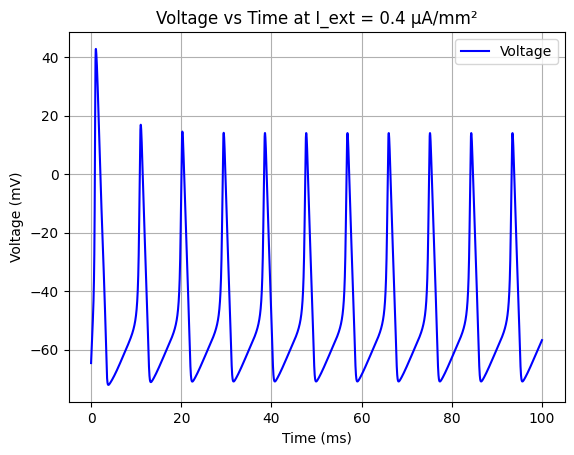

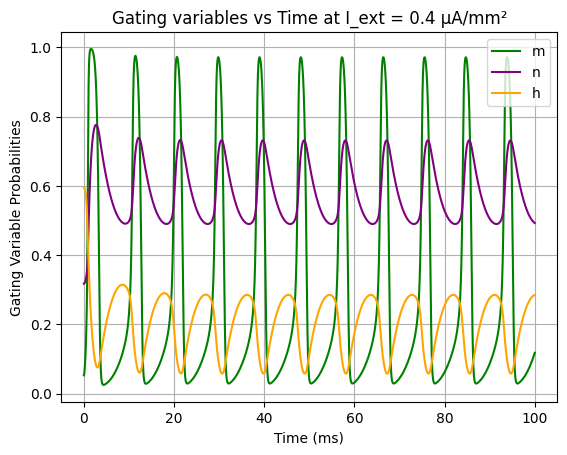

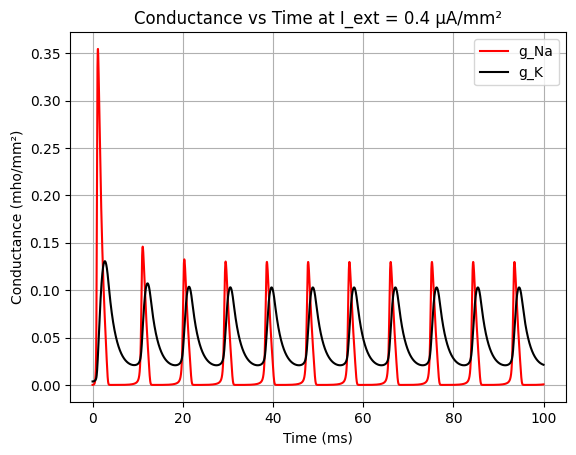

In [ ]:
plotter(0.4)

In [ ]:
def getSpikes(v):
    spikes = 0
    for i in range(1, len(v) - 1):
        if v[i] >= 10 and (v[i-1] < v[i] > v[i+1]): #The voltage must be greater than 10 (the assumed voltage threshold) to qualify as an action potential, and must be greater than its neighbours to be counted as a spike.
            spikes += 1
    return spikes

In [ ]:
HH = HHModel(dt = 0.01, iter = 10000)
v, m, n, h, gNa, gK = HH.model(I_app = 0.06)
spikes = signal.find_peaks(v, height = 10)
print(len(spikes[0]))
print(getSpikes(v))

2
2


In [ ]:
def getThresholds(spikesList):
    I1, I2, I3 = 0, 0, 0
    for i in range(1, len(spikesList) - 1):
        if spikesList[i] > 0 and spikesList[i-1] == 0:
            I1 = round(i * 0.001, 5)
        if spikesList[i] < spikesList[i+1] - 4:
            I2 = round(i * 0.001, 5)
        if spikesList[i] > spikesList[i+1] + 2:
            I3 = round(i * 0.001, 5)
    return I1, I2, I3

In [ ]:
currents = [i * 0.001 for i in range(600)] #This is the range of currents over which the voltage spikes were evaluated.
spikesList = []

for i in tqdm(currents): #tqdm enables the loading-bar graphic as seen below.
    HH = HHModel(dt = 0.01, iter = 50000)
    v, m, n, h, gNa, gK = HH.model(I_app = i)
    spikes = signal.find_peaks(v, height = 10)
    spikesCount = len(spikes[0])
    #spikesCount = getSpikes(v)
    spikesList.append(spikesCount)

  0%|          | 0/600 [00:00<?, ?it/s]

In [ ]:
I1, I2, I3 = getThresholds(spikesList)
print(f"The current threshold values I1, I2 and I3 are: {I1}, {I2} and {I3} μA/mm² respectively.")

The current threshold values I1, I2 and I3 are: 0.023, 0.062 and 0.469 μA/mm² respectively.


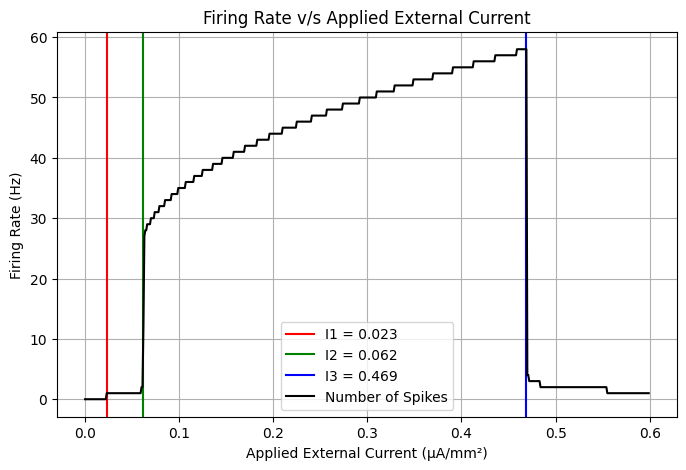

In [ ]:
plt.figure(figsize=(8,5))
plt.axvline(x = I1, color = 'red', label = f'I1 = {I1}')
plt.axvline(x = I2, color = 'green', label = f'I2 = {I2}')
plt.axvline(x = I3, color = 'blue', label = f'I3 = {I3}')
plt.plot(currents, spikesList, color = 'black', label = 'Number of Spikes')

plt.title('Firing Rate v/s Applied External Current')
plt.xlabel('Applied External Current (μA/mm²)')
plt.ylabel('Firing Rate (Hz)')

plt.grid()
plt.legend()
plt.show()

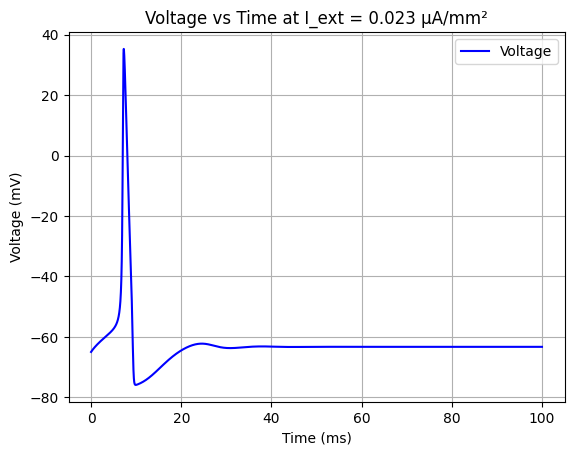

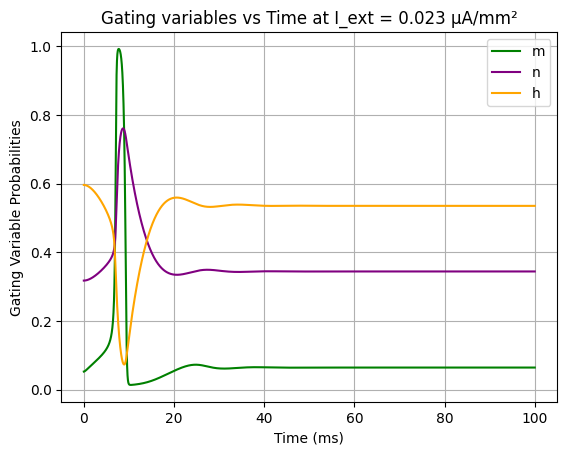

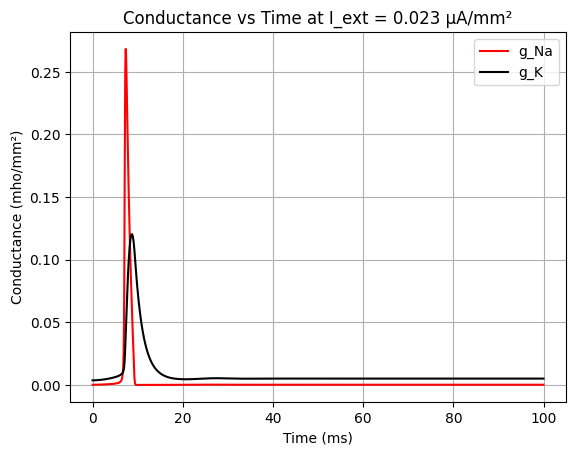

In [ ]:
plotter(I1)

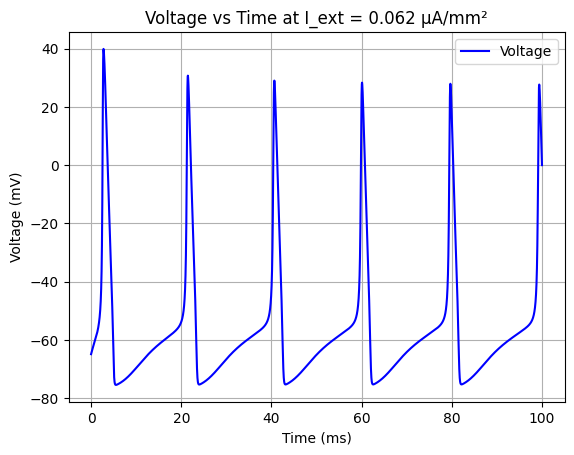

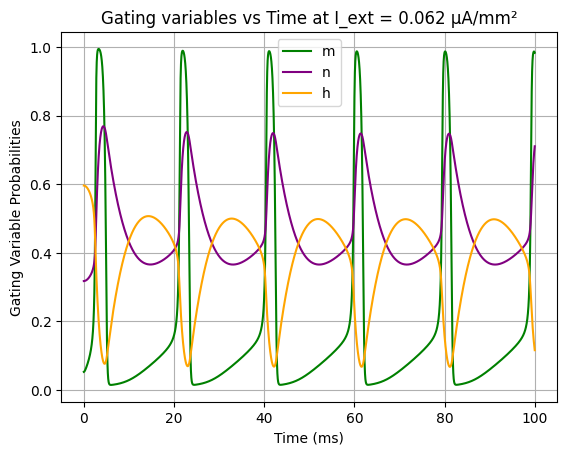

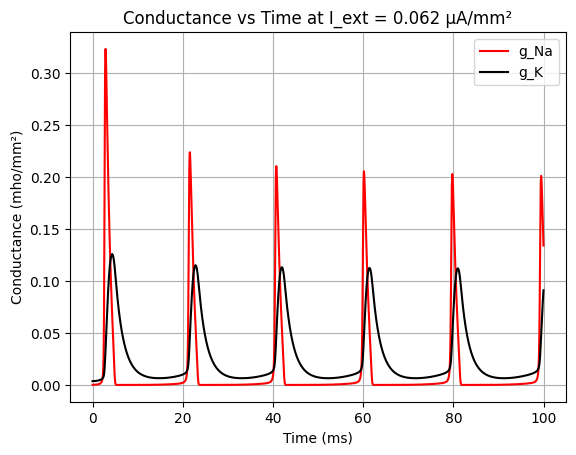

In [ ]:
plotter(I2)

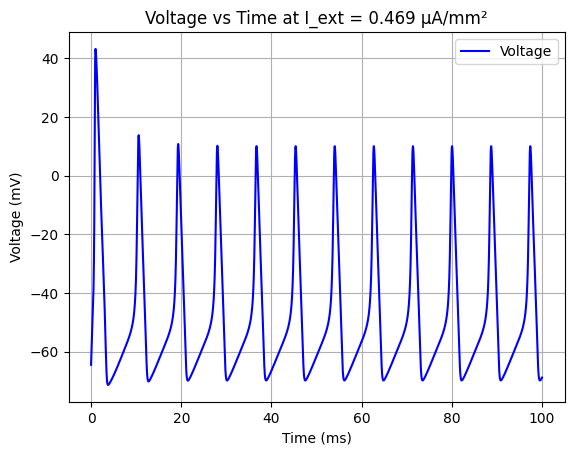

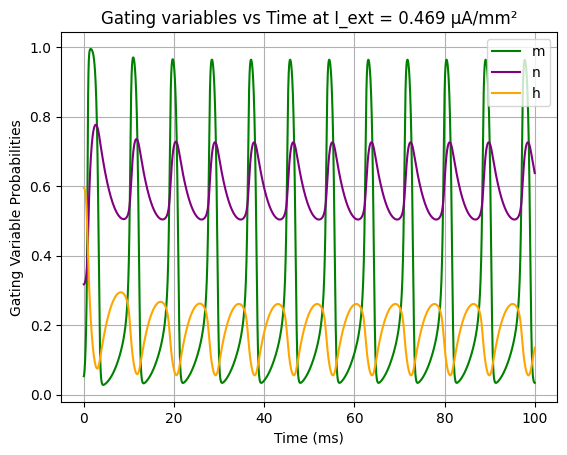

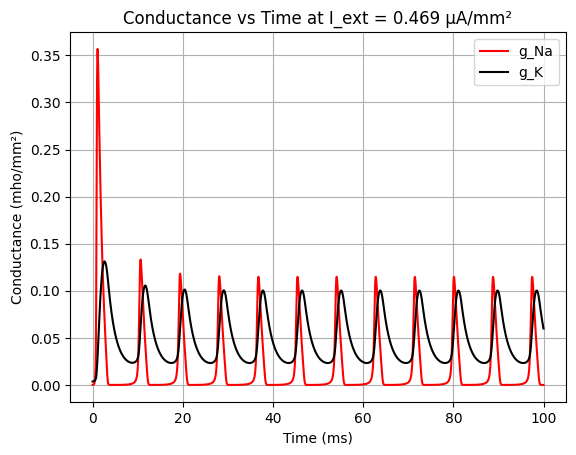

In [ ]:
plotter(I3)